In [63]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [2]:
!python -m pip install kaggle


   ------ --------------------------------- 1/6 [tqdm]
   ------ --------------------------------- 1/6 [tqdm]
   ------ --------------------------------- 1/6 [tqdm]
   ------------- -------------------------- 2/6 [python-slugify]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------- ------------------- 3/6 [protobuf]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kagglesdk]
   -------------------------- ------------- 4/6 [kaggle

In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
# importing data
titanic = pd.read_csv('./dataset/train.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [66]:
# 1. structure check

print(f"Titanic Dataset Shape: {titanic.shape}")
print(f"Titanic Dataset Columns: {titanic.columns}\n")
print(f"Titanic Dataset No. of Dimensions: {titanic.ndim}\n")
print(f"Categorical data columns: {titanic.select_dtypes(include=['category', 'object', 'bool']).columns}\n")
titanic.info()

Titanic Dataset Shape: (891, 12)
Titanic Dataset Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Titanic Dataset No. of Dimensions: 2

Categorical data columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     8

C:\Users\keval\AppData\Local\Temp\ipykernel_14748\3584052718.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical data columns: {titanic.select_dtypes(include=['category', 'object', 'bool']).columns}\n")


In [26]:
# 2. checking for missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# 3. Duplicates
print("Duplicated Data Says True! \n")
print(f"{titanic.duplicated()}\n")
print(f"Total number of duplicated rows: {titanic.duplicated().sum()}")

Duplicated Data Says True! 

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Total number of duplicated rows: 0


In [42]:
# 4. Summary statistics
print("Data Statistics : \n")
print(titanic.describe(), end="\n\n")
print(titanic.describe(include=object))

Data Statistics : 

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

                           Name   Sex  Ticket Cabin Embarked

C:\Users\keval\AppData\Local\Temp\ipykernel_23076\4250489447.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(titanic.describe(include=object))


Text(0.5, 1.0, 'Passenger Survival')

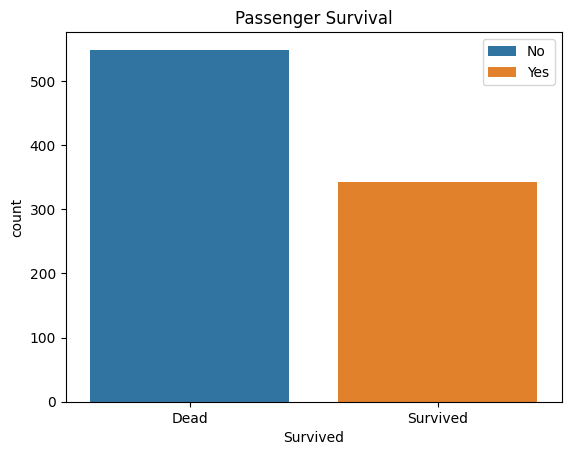

In [ ]:
# 5. Analysis

# 5.1 Count of survivals
titanic = pd.read_csv('./dataset/train.csv')
titanic["Survived"] = titanic["Survived"].map({0: "Dead", 1: "Survived"})
cntplt = sns.countplot(
    data=titanic, 
    x="Survived", 
    hue="Survived"
)
cntplt.legend(["No", "Yes"])
cntplt.set_title("Passenger Survival")

Text(0, 0.5, 'Mean Age')

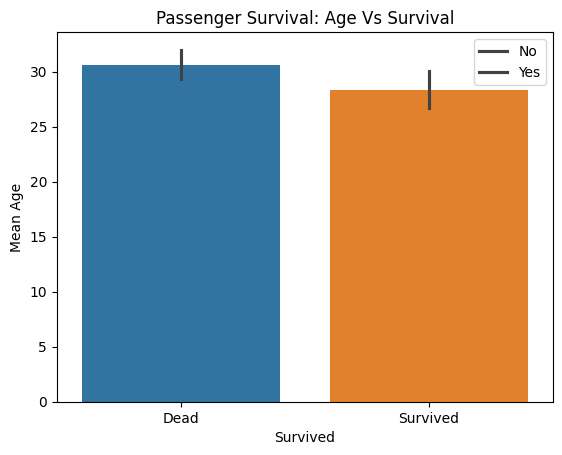

In [ ]:
# 5.2 Mean age of survivals
titanic = pd.read_csv('./dataset/train.csv')
titanic["Survived"] = titanic["Survived"].map({0: "Dead", 1: "Survived"})
cntplt = sns.barplot(
    data=titanic, 
    x="Survived", 
    y="Age", 
    hue="Survived"
)
cntplt.legend(["No", "Yes"])
cntplt.set_title("Passenger Survival: Age Vs Survival")
cntplt.set_ylabel("Mean Age")

Text(0, 0.5, 'Passenger Count')

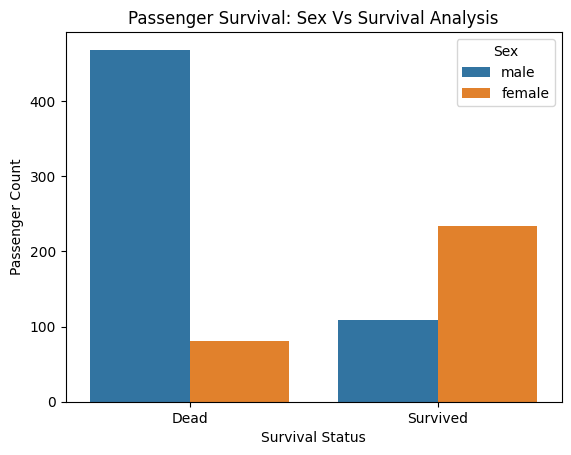

In [ ]:
# 5.3 Sex distribution of survivals
titanic = pd.read_csv('./dataset/train.csv')
titanic["Survived"] = titanic["Survived"].map({0: "Dead", 1: "Survived"})
cntplt = sns.countplot(
    data=titanic, 
    x="Survived",
    hue="Sex"
)
cntplt.set_title("Passenger Survival: Sex Vs Survival Analysis")
cntplt.legend(title="Sex")
cntplt.set_xlabel("Survival Status")
cntplt.set_ylabel("Passenger Count")

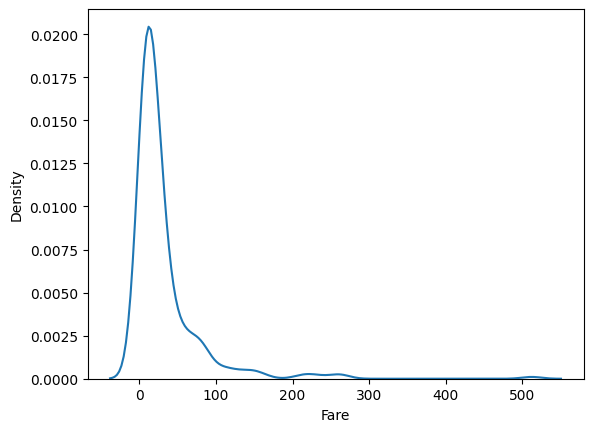

In [ ]:
# 5.4 fare distribution of survivals and dead ones
titanic = pd.read_csv('./dataset/train.csv')
cntplt = sns.kdeplot(
    data=titanic,
    x="Fare"
)
cntplt.set_title("Titanic Passenger : fare price distribution")

Survived      Dead  Survived
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


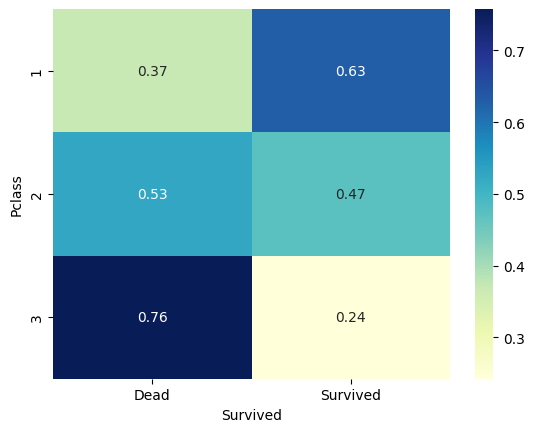

In [ ]:
# 5.5 passenger class and survival analysis
titanic = pd.read_csv('./dataset/train.csv')
titanic["Survived"] = titanic["Survived"].map({0: "Dead", 1: "Survived"})
# grp = titanic.groupby(['Pclass', 'Survived']).size().unstack() # we can also grp if we want to the numbers instead of percentage

ct = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index')
sns.heatmap(
    data=ct, 
    annot=True, 
    cmap="YlGnBu"
)
plt.show()

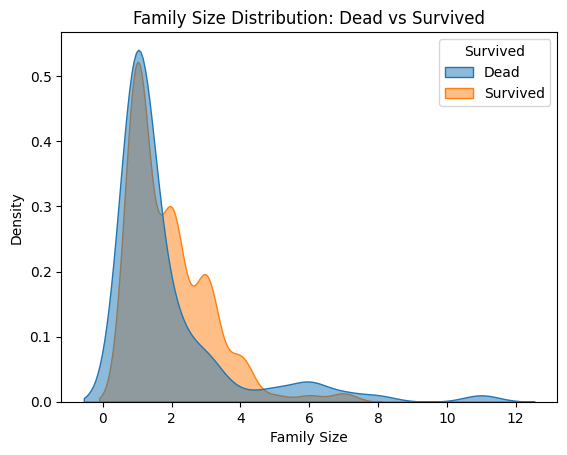

In [ ]:
# 5.6 family size vs survival
titanic = pd.read_csv('./dataset/train.csv')
titanic["Survived"] = titanic["Survived"].map({0: "Dead", 1: "Survived"})
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1

sns.kdeplot(
    data=titanic,
    x="FamilySize",
    hue="Survived",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Family Size Distribution: Dead vs Survived")
plt.xlabel("Family Size")
plt.show()

             PassengerId    Pclass       Age     SibSp     Parch      Fare
PassengerId     1.000000 -0.035144  0.036847 -0.057527 -0.001652  0.012658
Pclass         -0.035144  1.000000 -0.369226  0.083081  0.018443 -0.549500
Age             0.036847 -0.369226  1.000000 -0.308247 -0.189119  0.096067
SibSp          -0.057527  0.083081 -0.308247  1.000000  0.414838  0.159651
Parch          -0.001652  0.018443 -0.189119  0.414838  1.000000  0.216225
Fare            0.012658 -0.549500  0.096067  0.159651  0.216225  1.000000


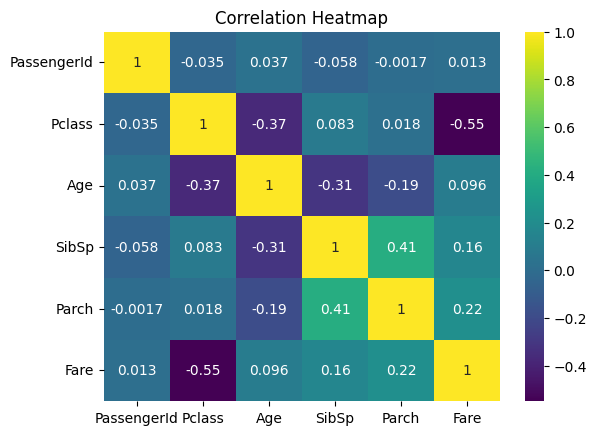

In [ ]:
# 6. Correlation check
corr_matrix = titanic.select_dtypes(include='number').corr()
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

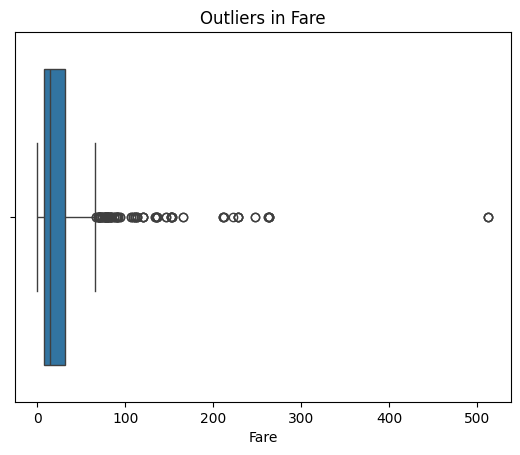

In [ ]:
# 7. Outlier detection
sns.boxplot(data=titanic, x="Fare")
plt.title("Outliers in Fare")
plt.show()

In [ ]:
# 8. Skewness check
titanic.select_dtypes(include='number').skew()

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

Number of null data of cabin: 687

Deck Info: 
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


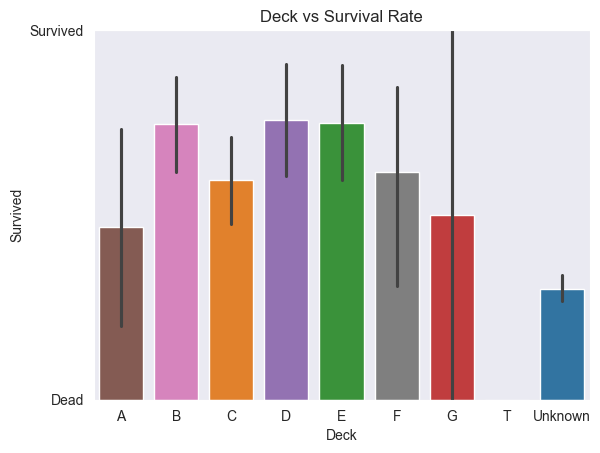

In [ ]:
# 9. Feature insights
# cabin vs survival analysis

print(f"Number of null data of cabin: {titanic['Cabin'].isnull().sum()}")
sns.set_style('darkgrid')
titanic["Deck"] = titanic["Cabin"].str[0]
titanic["Deck"] = titanic["Deck"].fillna("Unknown")
print("\nDeck Info: ")
print(titanic["Deck"].value_counts())
sns.barplot(
    data=titanic, 
    x="Deck", 
    y="Survived", 
    hue="Deck",
    order=sorted(titanic["Deck"].unique())
)

plt.title("Deck vs Survival Rate")
plt.ylim(0,1)
plt.show()